# FIFA World Cup 2026 — Fouls Analysis

# FIFA World Cup 2026 — Fouls Analysis

**Student Name:** Md Mubtasim Fuad Jenok  
**Student ID:** S399056  
**Unit:** S226 HIT140 Foundations of Data Science  
**Contribution:** Fouls Analysis

## Objective 1 — Analytic Task

### Analytic question

**Do teams that received at least one red card have a different average number of fouls per 90 minutes from teams that received no red cards?**

**Focal point:** Team disciplinary behaviour — fouls per 90 minutes.

**Objective 1 — Analytic Task**

### Analytic question
**Do teams that received at least one red card have a different average number of fouls per 90 minutes from teams that received no red cards?**

**Focal point:** Team disciplinary behaviour — fouls per 90 minutes.

This notebook covers:
1. Data loading and wrangling
2. Data preparation and sampling
3. Descriptive statistics
4. 95% confidence interval
5. Welch two-sample t-test
6. Visualisations
7. Interpretation and conclusion

> **Data source:** The supplied FIFA World Cup 2026 team-level dataset downloaded from the approved football statistics source used by the group.


## 1. Install/import the required libraries

This notebook is designed for **Google Colab**. The assessment requires the analysis and visualisations to be completed in Python.


In [1]:
# Run this cell first in Google Colab
!pip -q install xlrd

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Upload the dataset

In Google Colab, run the next cell and select the supplied `.xls` dataset.

The notebook accepts the uploaded file rather than depending on a local computer path.


In [3]:
from google.colab import files

uploaded = files.upload()

# Get the uploaded filename
file_name = next(iter(uploaded))
print("Uploaded file:", file_name)


Saving sportsref_download_foul.xls to sportsref_download_foul.xls
Uploaded file: sportsref_download_foul.xls


In [4]:
# Read the uploaded Sports-Reference/FBref-style .xls table
raw = pd.read_html(file_name)[0]

# Flatten multi-level column names if present
raw.columns = [c[1] if isinstance(c, tuple) else c for c in raw.columns]

# Display the original structure
print("Original dataset shape:", raw.shape)
display(raw.head())
print("\nColumns:")
print(list(raw.columns))


Original dataset shape: (48, 15)


,Squad,# Pl,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG
0,dz Algeria,22,4.0,3,0,0,29,40,4,40,30,44,NaN,NaN,0
1,ar Argentina,24,9.0,15,1,1,113,100,22,104,82,93,NaN,NaN,0
2,au Australia,23,4.3,5,0,0,46,38,1,70,29,34,NaN,NaN,1
3,at Austria,20,4.0,5,0,0,47,28,11,59,41,29,NaN,NaN,0
4,be Belgium,23,6.3,6,1,0,78,68,8,114,50,47,NaN,NaN,0



Columns:
['Squad', '# Pl', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG']


## 3. Data wrangling and preparation

The dataset contains team-level tournament statistics. The variables used for this task are:

- `90s` — team playing time expressed in 90-minute units
- `Fls` — fouls committed
- `CrdR` — red cards

Because teams may have different amounts of playing time, raw foul totals are converted to **fouls per 90 minutes**:

**Fouls per 90 = Fouls / 90s**

For the statistical comparison, teams are divided into two groups:
- At least one red card
- No red card


In [5]:
# Rename the first column to make the team field easier to work with
raw = raw.rename(columns={raw.columns[0]: "Squad"})

def clean_team_name(value):
    value = str(value)
    # Fix common encoding issue in exported team names
    try:
        value = value.encode("latin1").decode("utf-8")
    except Exception:
        pass

    parts = value.split(" ", 1)
    return parts[1] if len(parts) > 1 else value

raw["Team"] = raw["Squad"].apply(clean_team_name)

# Convert required variables to numeric
for column in ["90s", "Fls", "CrdR"]:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

# Keep only variables required for this task
data = raw[["Team", "90s", "Fls", "CrdR"]].dropna().copy()

# Calculate the standardised foul rate
data["Fouls_per_90"] = data["Fls"] / data["90s"]

# Create the two comparison groups
data["Red_card_group"] = np.where(
    data["CrdR"] > 0,
    "At least 1 red card",
    "No red card"
)

print("Cleaned dataset shape:", data.shape)
display(data.head(10))


Cleaned dataset shape: (48, 6)


,Team,90s,Fls,CrdR,Fouls_per_90,Red_card_group
0,Algeria,4.0,29,0,7.250000,No red card
1,Argentina,9.0,113,1,12.555556,At least 1 red card
2,Australia,4.3,46,0,10.697674,No red card
3,Austria,4.0,47,0,11.750000,No red card
4,Belgium,6.3,78,1,12.380952,At least 1 red card
5,Bosnia–Herz,4.0,60,1,15.000000,At least 1 red card
6,Brazil,5.0,51,0,10.200000,No red card
7,Cabo Verde,4.3,27,0,6.279070,No red card
8,Canada,5.0,72,0,14.400000,No red card
9,Colombia,5.3,70,0,13.207547,No red card


## 4. Check the cleaned data

The supplied dataset contains the team-level World Cup data used for this task. We check the number of teams and the two red-card groups before sampling.


In [6]:
print("Number of teams:", len(data))
print("\nRed-card groups:")
display(data["Red_card_group"].value_counts())

print("\nMissing values:")
display(data.isna().sum())

print("\nFouls per 90 summary:")
display(data["Fouls_per_90"].describe())


Number of teams: 48

Red-card groups:


,count
Red_card_group,
No red card,35
At least 1 red card,13



Missing values:


,0
Team,0
90s,0
Fls,0
CrdR,0
Fouls_per_90,0
Red_card_group,0



Fouls per 90 summary:


,Fouls_per_90
count,48.000000
mean,11.301791
std,2.307666
min,6.279070
25%,10.089759
50%,11.166038
75%,12.398922
max,18.333333


## 5. Data preparation and sampling

The full supplied dataset contains **48 teams**.

To demonstrate sampling, a **stratified random sample** is taken from the two red-card strata. The sample uses approximately 80% of each group:

- 10 teams with at least one red card
- 28 teams with no red card
- **38 teams in total**

A fixed random seed (`42`) makes the sample reproducible.


In [7]:
# Stratified random sampling
red_card_sample = data[data["CrdR"] > 0].sample(n=10, random_state=42)
no_red_card_sample = data[data["CrdR"] == 0].sample(n=28, random_state=42)

sample = pd.concat([red_card_sample, no_red_card_sample])
sample = sample.sample(frac=1, random_state=42).reset_index(drop=True)

sample.insert(0, "Sample_ID", range(1, len(sample) + 1))

print("Sample size:", len(sample))
display(sample)


Sample size: 38


,Sample_ID,Team,90s,Fls,CrdR,Fouls_per_90,Red_card_group
0,1,New Zealand,3.0,32,0,10.666667,No red card
1,2,Netherlands,4.3,44,0,10.232558,No red card
2,3,Iraq,3.0,27,1,9.000000,At least 1 red card
3,4,Morocco,6.3,74,0,11.746032,No red card
4,5,Tunisia,3.0,27,0,9.000000,No red card
5,6,Canada,5.0,72,0,14.400000,No red card
6,7,Belgium,6.3,78,1,12.380952,At least 1 red card
7,8,Czechia,3.0,37,0,12.333333,No red card
8,9,IR Iran,3.0,35,0,11.666667,No red card
9,10,Senegal,4.3,36,0,8.372093,No red card


## 6. Descriptive statistics

We first describe the distribution of fouls per 90 minutes using:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum


In [8]:
fouls = sample["Fouls_per_90"]

descriptive = pd.Series({
    "Sample size": len(fouls),
    "Mean fouls per 90": fouls.mean(),
    "Median": fouls.median(),
    "Standard deviation": fouls.std(ddof=1),
    "Minimum": fouls.min(),
    "Maximum": fouls.max()
})

display(descriptive.to_frame("Value").round(3))


,Value
Sample size,38.000
Mean fouls per 90,10.971
Median,10.682
Standard deviation,2.280
Minimum,6.279
Maximum,18.333


## 7. 95% Confidence Interval

We estimate a **95% confidence interval for the population mean foul rate** using the sample mean and the t-distribution.

**Interpretation:** We use the interval to estimate a plausible range for the mean fouls per 90 minutes in the population represented by the dataset.


In [9]:
n = len(fouls)
mean_fouls = fouls.mean()
sd_fouls = fouls.std(ddof=1)
standard_error = sd_fouls / np.sqrt(n)

ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean_fouls,
    scale=standard_error
)

print(f"Sample mean: {mean_fouls:.2f} fouls per 90")
print(f"95% confidence interval: {ci_low:.2f} to {ci_high:.2f} fouls per 90")


Sample mean: 10.97 fouls per 90
95% confidence interval: 10.22 to 11.72 fouls per 90


## 8. Visualisation — distribution of fouls

This histogram shows how fouls per 90 minutes are distributed across the sampled teams.


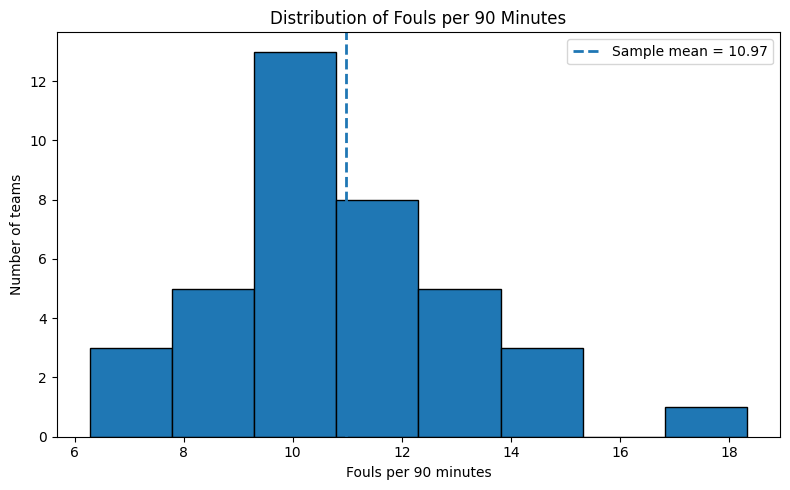

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(fouls, bins=8, edgecolor="black")
plt.axvline(
    mean_fouls,
    linestyle="--",
    linewidth=2,
    label=f"Sample mean = {mean_fouls:.2f}"
)
plt.xlabel("Fouls per 90 minutes")
plt.ylabel("Number of teams")
plt.title("Distribution of Fouls per 90 Minutes")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Two-sample t-test

### Hypotheses

**H₀:** The mean fouls per 90 minutes are equal for teams with at least one red card and teams with no red cards.

**H₁:** The mean fouls per 90 minutes are different between the two groups.

A **Welch two-sample t-test** is used because the two groups do not have equal sample sizes and Welch's test does not require equal population variances.

Significance level:

**α = 0.05**


In [11]:
red_group = sample.loc[
    sample["CrdR"] > 0, "Fouls_per_90"
]

no_red_group = sample.loc[
    sample["CrdR"] == 0, "Fouls_per_90"
]

test_result = stats.ttest_ind(
    red_group,
    no_red_group,
    equal_var=False
)

print(f"Red-card group mean: {red_group.mean():.2f} fouls/90")
print(f"No-red-card group mean: {no_red_group.mean():.2f} fouls/90")
print(f"Welch t-statistic: {test_result.statistic:.3f}")
print(f"p-value: {test_result.pvalue:.3f}")


Red-card group mean: 11.42 fouls/90
No-red-card group mean: 10.81 fouls/90
Welch t-statistic: 0.822
p-value: 0.420


## 10. Visualisation — comparison of the two groups


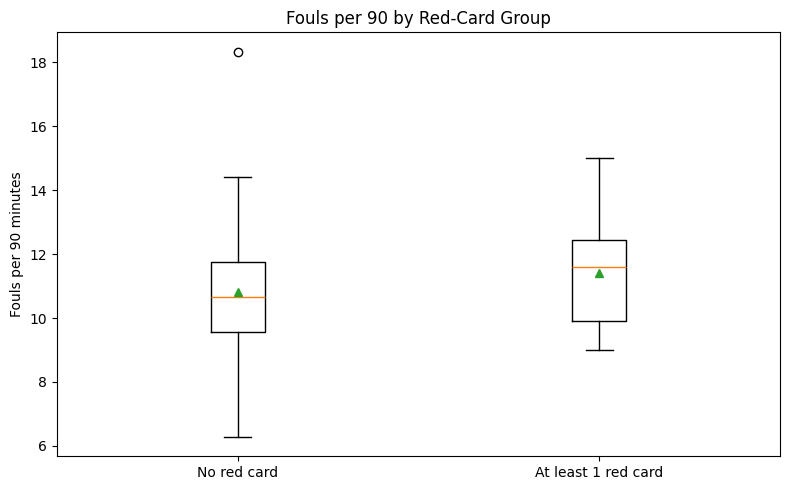

In [12]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [no_red_group, red_group],
    tick_labels=["No red card", "At least 1 red card"],
    showmeans=True
)

plt.ylabel("Fouls per 90 minutes")
plt.title("Fouls per 90 by Red-Card Group")
plt.tight_layout()
plt.show()


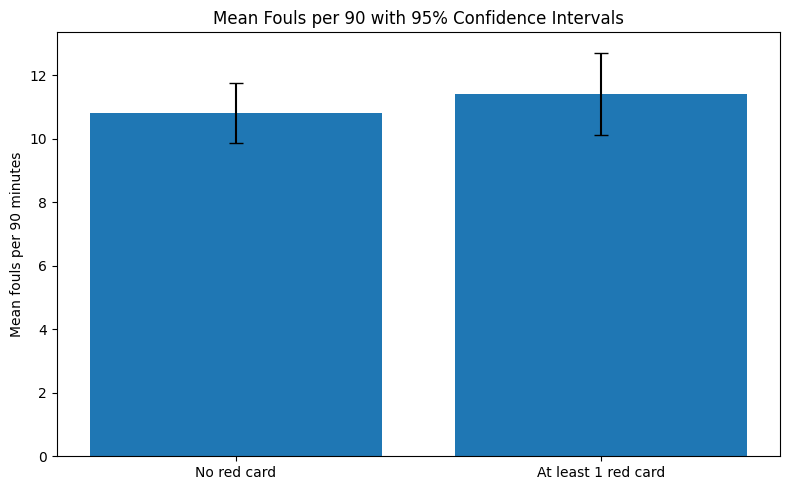

In [13]:
# Group means with 95% confidence intervals

group_means = [
    no_red_group.mean(),
    red_group.mean()
]

group_errors = [
    stats.t.ppf(0.975, len(no_red_group)-1)
    * no_red_group.std(ddof=1) / np.sqrt(len(no_red_group)),

    stats.t.ppf(0.975, len(red_group)-1)
    * red_group.std(ddof=1) / np.sqrt(len(red_group))
]

plt.figure(figsize=(8, 5))
plt.bar(
    ["No red card", "At least 1 red card"],
    group_means,
    yerr=group_errors,
    capsize=5
)
plt.ylabel("Mean fouls per 90 minutes")
plt.title("Mean Fouls per 90 with 95% Confidence Intervals")
plt.tight_layout()
plt.show()


## 11. Statistical decision and conclusion


In [14]:
alpha = 0.05

if test_result.pvalue < alpha:
    decision = "Reject H0"
    conclusion = (
        "There is statistically significant evidence of a difference "
        "in mean fouls per 90 between the two groups."
    )
else:
    decision = "Fail to reject H0"
    conclusion = (
        "There is not enough statistical evidence to conclude that "
        "the mean foul rate differs between the two groups."
    )

print("Decision:", decision)
print("Conclusion:", conclusion)


Decision: Fail to reject H0
Conclusion: There is not enough statistical evidence to conclude that the mean foul rate differs between the two groups.


## 12. Results to report in the presentation

### Key results

- **Sample:** 38 teams
- **Mean:** 10.97 fouls per 90
- **Median:** 10.68
- **Standard deviation:** 2.28
- **95% CI:** 10.22–11.72 fouls per 90
- **At least 1 red card:** 11.42 fouls per 90
- **No red card:** 10.81 fouls per 90
- **Welch t:** 0.822
- **p-value:** 0.420

### Conclusion

Because **p = 0.420 > 0.05**, we **fail to reject H₀**.

There is not enough statistical evidence in this sample to conclude that the average foul rate differs between teams with at least one red card and teams with no red cards.

**Important:** This result does not prove that the two groups are identical, and it does not show that red cards cause fouls.


## 13. Save the cleaned data and analysis sample

These files can be downloaded from Colab and placed in the GitHub repository with the notebook.


In [15]:
data.to_csv("cleaned_foul_dataset.csv", index=False)
sample.to_csv("analysis_sample.csv", index=False)

print("Saved:")
print("- cleaned_foul_dataset.csv")
print("- analysis_sample.csv")


Saved:
- cleaned_foul_dataset.csv
- analysis_sample.csv


In [16]:
from google.colab import files

files.download("cleaned_foul_dataset.csv")
files.download("analysis_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>